# Customer Segmentation & RFM Analysis

## Project Overview

Customer segmentation is a business analytics technique used to group customers based on their purchasing behavior and value to the business. Understanding customer segments helps organizations develop targeted marketing strategies, improve customer retention, and maximize revenue.

In this project, RFM (Recency, Frequency, Monetary) Analysis is used to evaluate customer behavior and identify high-value customers. The analysis focuses on customer purchase history to create meaningful segments such as Champions, Loyal Customers, At-Risk Customers, and Lost Customers.

## Objectives

- Analyze customer purchasing behavior.
- Identify valuable customer segments using RFM Analysis.
- Understand customer engagement and spending patterns.
- Generate actionable business insights.
- Provide recommendations for customer retention and marketing strategies.

## Dataset

The dataset contains online retail transaction records, including customer purchases, product details, quantities, prices, and transaction dates.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Business Problem

Businesses often struggle to identify which customers contribute the most value and which customers are at risk of becoming inactive. By segmenting customers based on purchasing behavior, organizations can develop targeted strategies to improve customer satisfaction, retention, and profitability.

## 1. Import Libraries



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset



In [4]:
df = pd.read_excel("../data/Online Retail.xlsx")

## 3. Data Understanding



### Objective
Determine the number of rows and columns in the dataset to understand its overall size and scale.

In [5]:
# Display the number of rows and columns in the dataset
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 541909
Number of Columns: 8


In [6]:
# Display dataset structure, data types, and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# Display first 5 rows of the dataset

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
# Display last 5 rows of the dataset

df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [9]:
# Display 5 random rows from the dataset

df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [10]:
# Display all column names

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [11]:
# Generate descriptive statistics for numerical columns

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
# Generate descriptive statistics for categorical columns

df.describe(include='object')

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [13]:
# Display missing values count for each column

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
# Calculate percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

CustomerID     24.926694
Description     0.268311
InvoiceNo       0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [15]:
# Count duplicate records

df.duplicated().sum()

np.int64(5268)

In [16]:
# Count unique values in each column

df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

## 4. Data Cleaning



## Objective : Handle Missing Values

Identify and analyze missing values to determine the appropriate data cleaning strategy.

In [17]:
# Count missing values in each column

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
# Display rows where CustomerID is missing

df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


### Insight

The dataset contains missing values in the Description and CustomerID columns.

- Description has a relatively small number of missing values.
- CustomerID has a substantial number of missing values.
- Since RFM Analysis is customer-centric, CustomerID is a critical field.
- Transactions without CustomerID cannot be associated with a specific customer and therefore cannot be included in customer segmentation.

## Objective : Remove Missing Customer IDs
Remove transactions with missing CustomerID values because they cannot be linked to individual customers for RFM analysis.

In [19]:
# Remove rows with missing CustomerID

df = df.dropna(subset=['CustomerID'])

# Verify removal
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [20]:
#Dataset Shape After Removing Missing values:
df.shape

(406829, 8)

### Insight

Transactions with missing CustomerID values were removed because customer identification is essential for calculating Recency, Frequency, and Monetary metrics.

Removing these records ensures that all remaining transactions can be accurately assigned to individual customers.

## Objective : Identify Duplicate Reacords
Identify duplicate records that may lead to inaccurate customer and revenue analysis.

In [21]:
# Count duplicate records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 5225


### Insight

The dataset contains 5,225 duplicate records. Duplicate transactions can lead to inflated revenue calculations, inaccurate purchase frequencies, and misleading customer segment assignments. These records should be removed to ensure accurate analysis.

## Objective : Remove Duplicate Records 
Remove duplicate records to improve data quality and prevent double-counting of transactions.

In [22]:
# Remove duplicate records

df = df.drop_duplicates()

# Verify removal
print(f"Dataset Shape After Removing Duplicates: {df.shape}")

Dataset Shape After Removing Duplicates: (401604, 8)


### Insight

Duplicate records were successfully removed. This ensures that each transaction is counted only once, resulting in more accurate revenue calculations and customer behavior analysis.

## Objective : Analyze Quantity Column

Examine the Quantity column to identify invalid transactions such as product returns and cancellations.

In [23]:
# Summary statistics for Quantity

df['Quantity'].describe()

count    401604.000000
mean         12.183273
std         250.283037
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [24]:
# Count transactions with non-positive quantities

(df['Quantity'] <= 0).sum()

np.int64(8872)

## Objective : Investigate Negative Quantities
Investigate transactions with negative quantities to determine whether they represent returns or cancellations.

In [25]:
# View sample transactions with negative quantities

df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [26]:
# Check invoice numbers of negative quantity transactions
 
df[df['Quantity'] < 0]['InvoiceNo'].head()

141    C536379
154    C536383
235    C536391
236    C536391
237    C536391
Name: InvoiceNo, dtype: object

## Objective : Cancelled Transactions Analysis

Identify cancelled transactions and evaluate their impact on customer purchase analysis.

In [27]:
# View sample cancelled transactions

df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


### Insight

Investigation revealed that transactions with negative quantities have invoice numbers beginning with 'C', indicating cancelled orders or product returns.

Since RFM Analysis focuses on completed purchases and customer spending behavior, cancelled transactions will be excluded from further analysis.

## Objective : Remove Cancelled Transactions
Remove cancelled transactions to ensure that customer purchase behavior is based only on completed sales.

In [28]:
# Keep only completed purchases

df = df[df['Quantity'] > 0]

# Verify dataset shape
print(df.shape)

(392732, 8)


### Insight

Cancelled and returned transactions were removed from the dataset. The remaining records represent completed purchases and provide a reliable foundation for customer segmentation and revenue analysis.

## Objective : Check UnitPrice
Examine product prices and identify invalid pricing records.

In [29]:
df['UnitPrice'].describe()

count    392732.000000
mean          3.125596
std          22.240725
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [30]:
# Count records with zero or negative prices
(df['UnitPrice'] <= 0).sum()

np.int64(40)

## Objective : Handle Invalid Prices
Identify and remove transactions with invalid product prices to ensure accurate revenue calculations.

In [31]:
# Remove transactions with zero or negative prices
df = df[df['UnitPrice'] > 0]

# Verify dataset shape
print(df.shape)

(392692, 8)


### Insight

A small number of transactions contained invalid product prices. These records were removed because they do not contribute meaningful revenue and may negatively affect monetary analysis.

## Objective : Create Revenue Column
Calculate transaction revenue for each purchase.

In [32]:
# Calculate revenue generated by each transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Display sample records
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Insight

A new TotalPrice column was created to represent revenue generated from each transaction. This metric will be used extensively in revenue analysis and RFM calculations.

## Objective : Convert CustomerID
Convert CustomerID to integer format for consistency and easier customer analysis.

In [33]:
# Convert CustomerID to integer type
df['CustomerID'] = df['CustomerID'].astype(int)

df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
dtype: object

### Insight

CustomerID was converted to integer format to improve data consistency and support customer-level analysis.

## Final Data Cleaning Summary
### Objective
Summarize the data cleaning process and review the final dataset.

In [34]:
# Final dataset shape
print(f"Final Dataset Shape: {df.shape}")

Final Dataset Shape: (392692, 9)


### Insight

Data cleaning included:

- Removing records with missing Customer IDs
- Removing duplicate transactions
- Removing cancelled orders and returns
- Removing invalid pricing records
- Creating a revenue column (TotalPrice)

The resulting dataset contains clean and reliable transaction records suitable for exploratory analysis and customer segmentation.

## 5. Exploratory Data Analysis (EDA)



## 1: Revenue by Country
### Objective
Identify the countries generating the highest revenue and evaluate their contribution to overall sales performance.

In [35]:
# Calculate revenue generated by each country
country_revenue = (
    df.groupby('Country')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
)

# Display top 10 countries
country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

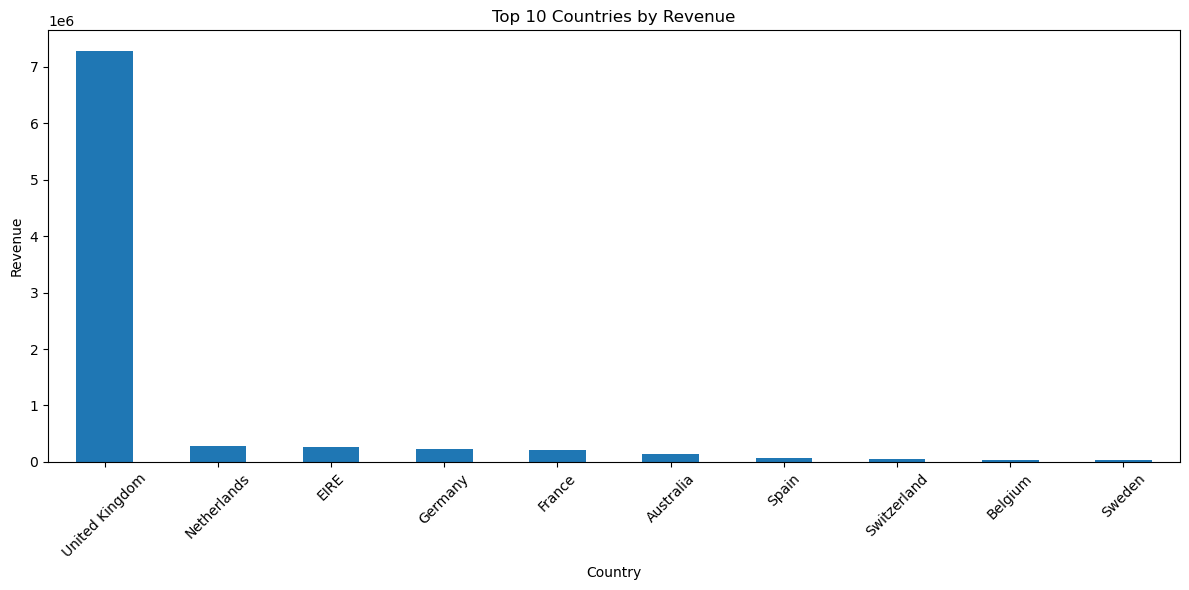

In [36]:
#Visualization
# Top 10 countries by revenue
top_10_countries = country_revenue.head(10)

plt.figure(figsize=(12,6))

top_10_countries.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../images/top_10_countries_revenue.png', bbox_inches='tight')

plt.show()

### Insight

The United Kingdom dominates revenue generation with sales exceeding 7.28 million, significantly outperforming all other countries. Revenue from the United Kingdom is substantially higher than the second-ranked country, the Netherlands, indicating a strong concentration of sales within the domestic market.

Among international markets, the Netherlands, EIRE, Germany, and France are the leading contributors, suggesting that these countries represent important growth opportunities outside the United Kingdom.

The large gap between the United Kingdom and other countries highlights a potential business dependency on a single market, which may increase risk if demand declines in that region.

## 2: Top Products by Revenue
### Objective
Identify the products generating the highest revenue and evaluate their contribution to overall business performance.

In [37]:
# Calculate revenue by product
product_revenue = (
    df.groupby('Description')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
)

# Display top 10 products
product_revenue.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

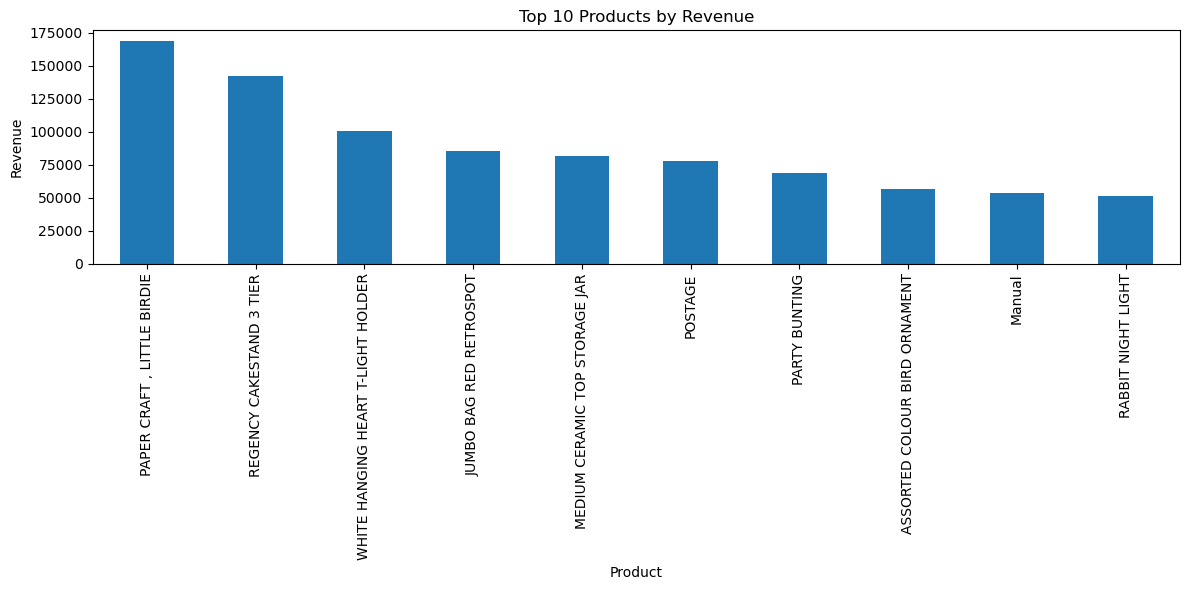

In [38]:
#Visualization
# Top 10 products by revenue
top_10_products = product_revenue.head(10)

plt.figure(figsize=(12,6))

top_10_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig('../images/top_10_products_revenue.png', bbox_inches='tight')

plt.show()


### Insight

PAPER CRAFT, LITTLE BIRDIE generated the highest revenue among all products, followed by REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER.

The revenue distribution indicates that a relatively small group of products contributes a significant portion of total sales, highlighting the importance of high-performing products to overall business performance.

Additionally, entries such as POSTAGE and Manual appear among the highest revenue contributors. These represent operational or administrative transactions rather than physical products and should be interpreted separately from product sales.

The results suggest that customer demand is concentrated around a limited number of popular products, creating opportunities for targeted inventory planning and promotional campaigns.

## 3: Top Products by Quantity Sold
### Objective
Identify the products with the highest sales volume and understand customer purchasing preferences.

In [39]:
# Calculate quantity sold by product
product_quantity = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

# Display top 10 products by quantity sold
product_quantity.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

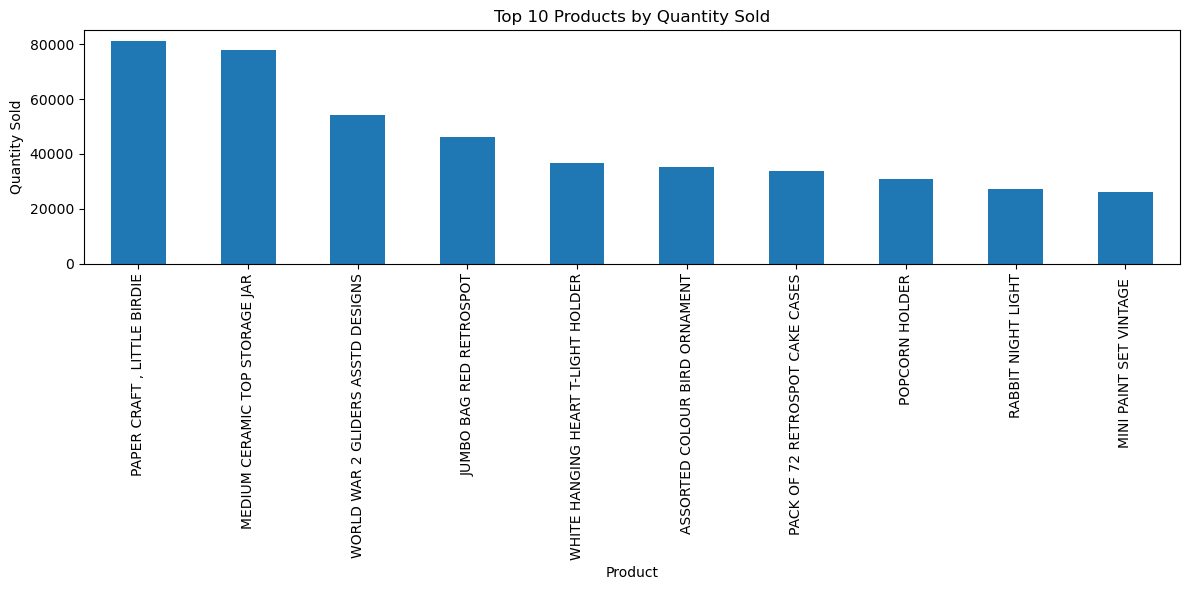

In [40]:
#Visualization
# Top 10 products by quantity sold
top_10_quantity = product_quantity.head(10)

plt.figure(figsize=(12,6))

top_10_quantity.plot(kind='bar')

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig('../images/top_10_products_quantity.png', bbox_inches='tight')

plt.show()

### Insight

PAPER CRAFT, LITTLE BIRDIE is both the highest revenue-generating product and the most frequently purchased product, indicating strong customer demand and significant business value.

MEDIUM CERAMIC TOP STORAGE JAR and WORLD WAR 2 GLIDERS ASSTD DESIGNS rank among the highest-selling products by volume, demonstrating their popularity among customers.

A comparison between revenue rankings and quantity rankings reveals that not all high-revenue products are high-volume products. Some products generate substantial revenue due to higher prices rather than larger sales volumes.

This distinction highlights the importance of analyzing both sales volume and revenue when evaluating product performance.

## 4: Monthly Revenue Trend
### Objective
Analyze revenue trends over time and identify seasonal patterns in customer purchasing behavior.

In [41]:
# Create year-month feature
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [42]:
# Calculate monthly revenue
monthly_revenue = (
    df.groupby('YearMonth')['TotalPrice']
      .sum()
)

monthly_revenue

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

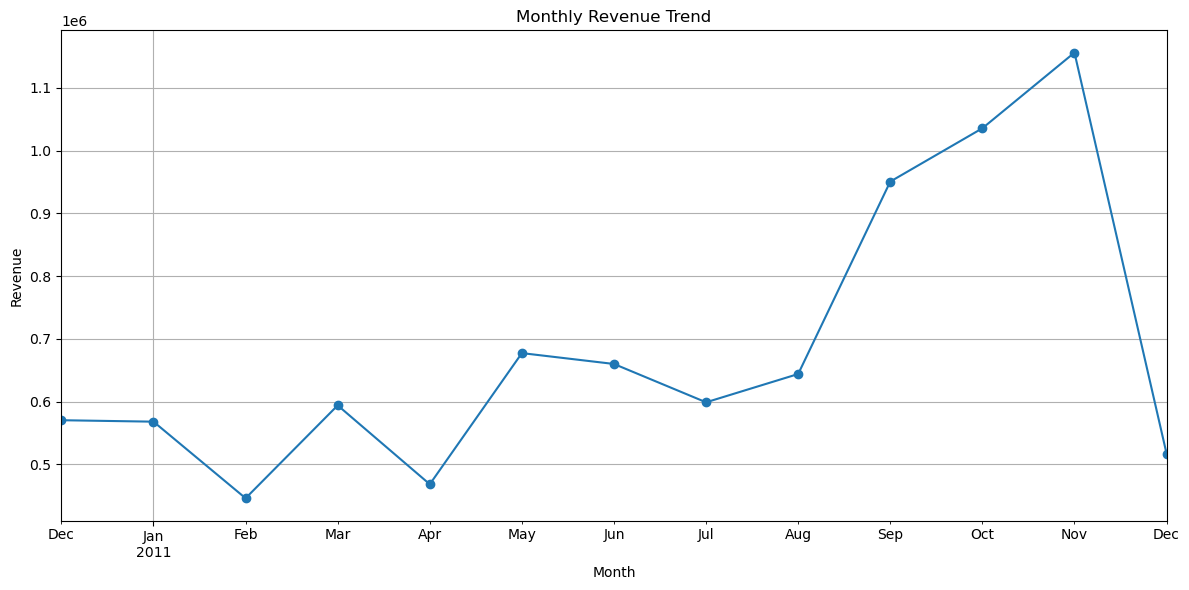

In [43]:
#Visualization
plt.figure(figsize=(12,6))

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.tight_layout()

plt.savefig('../images/monthly_revenue_trend.png', bbox_inches='tight')

plt.show()

### Insight

Monthly revenue analysis reveals a clear upward trend throughout 2011, indicating business growth and increasing customer demand over time.

Revenue remained relatively stable during the first half of the year, generally ranging between 446,000 and 677,000. However, a significant increase is observed from September onward.

The highest revenue was recorded in November 2011, exceeding 1.15 million, followed by October and September. This suggests strong seasonal demand during the final quarter of the year, likely influenced by holiday shopping and festive purchasing behavior.

Revenue declined in December 2011 compared to November. This decrease may be attributed to the dataset containing only partial December records rather than an actual decline in business performance.

## 5: Top Customers by Revenue
### Objective
Identify the highest-value customers based on total revenue contribution.

In [44]:
# Calculate revenue generated by each customer
customer_revenue = (
    df.groupby('CustomerID')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
)

# Display top 10 customers
customer_revenue.head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64

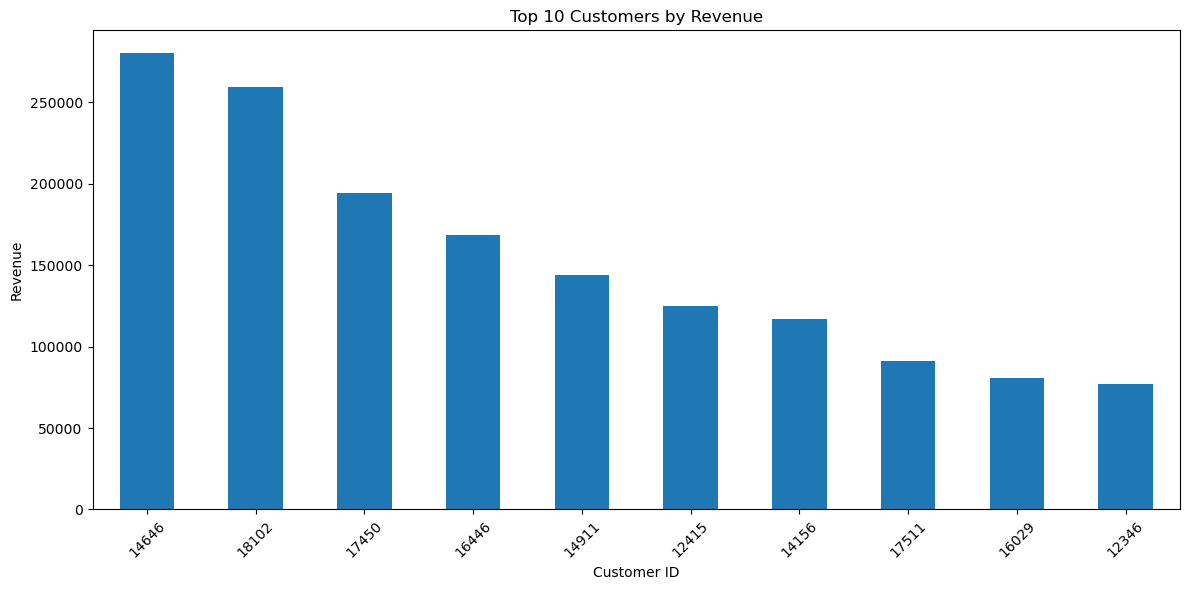

In [45]:
#Visualization
# Top 10 customers by revenue
top_customers = customer_revenue.head(10)

plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../images/top_10_customers_revenue.png', bbox_inches='tight')

plt.show()

### Insight

Customer revenue analysis reveals a significant concentration of revenue among a small group of customers.

Customer 14646 generated the highest revenue, contributing over 280,000 in sales, followed by customers 18102 and 17450. The substantial gap between these top customers and the average customer suggests that a relatively small number of customers account for a large share of total revenue.

This pattern is common in retail businesses and aligns with the Pareto Principle (80/20 Rule), where a minority of customers contribute a majority of business value.

Identifying and retaining these high-value customers is critical because losing even a few of them could have a noticeable impact on overall revenue.

## 6: Customer Purchase Frequency
### Objective
Analyze how frequently customers make purchases and understand the distribution of customer activity.

In [46]:
# Calculate number of transactions per customer
customer_frequency = (
    df.groupby('CustomerID')['InvoiceNo']
      .nunique()
)

customer_frequency.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

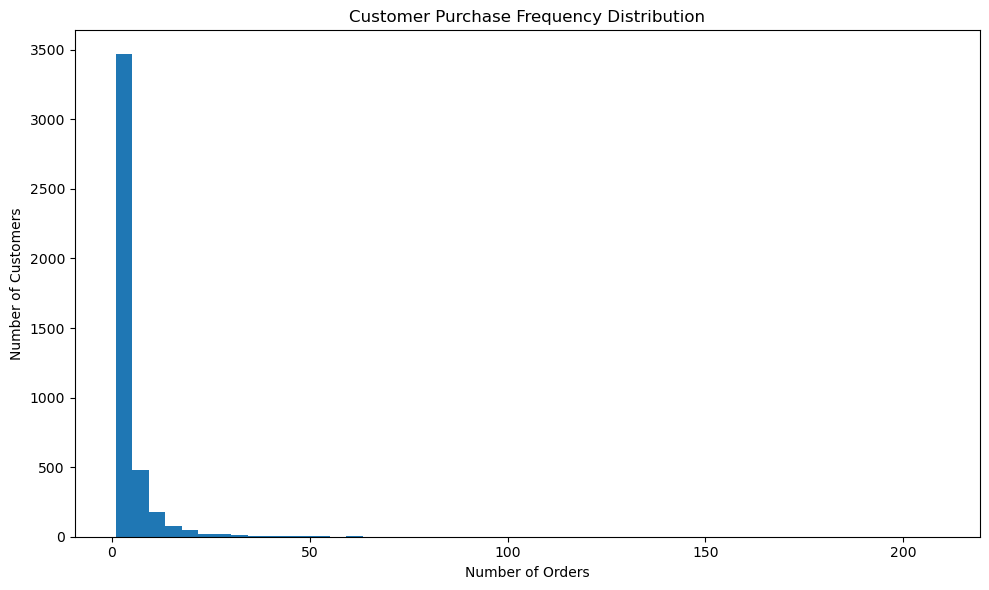

In [47]:
#Visualization
plt.figure(figsize=(10,6))

plt.hist(customer_frequency, bins=50)

plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()

plt.savefig('../images/customer_purchase_frequency.png',
            bbox_inches='tight')

plt.show()

### Insight

Customer purchase frequency analysis shows that most customers make relatively few purchases.

The median customer completed only 2 orders, while 75% of customers placed 5 or fewer orders. This indicates that a large portion of the customer base consists of occasional buyers rather than highly active customers.

However, the maximum purchase frequency reaches 209 orders, demonstrating the presence of a small group of highly engaged customers who purchase significantly more often than the average customer.

The large difference between the average frequency (4.27 orders) and the maximum frequency (209 orders) suggests a highly skewed distribution, where a small number of customers contribute a disproportionately large share of purchasing activity.

## EDA Summary

### Key Findings

#### Geographic Analysis

* The United Kingdom generated the highest revenue by a significant margin, indicating that the business is heavily dependent on its domestic market.
* The Netherlands, EIRE, Germany, and France emerged as the strongest international markets.

#### Product Analysis

* PAPER CRAFT, LITTLE BIRDIE was the highest revenue-generating product and also the most frequently purchased product.
* Several products generated high revenue despite lower sales volumes, highlighting the influence of product pricing on overall revenue.
* A relatively small group of products contributed a substantial portion of total sales.

#### Sales Trend Analysis

* Revenue showed a clear growth trend throughout 2011.
* The highest revenue was recorded in November 2011, suggesting strong seasonal demand during the final quarter of the year.
* Sales activity increased significantly from September onward.

#### Customer Analysis

* Revenue was concentrated among a small group of high-value customers.
* Customer 14646 generated the highest revenue contribution.
* Most customers placed relatively few orders, while a small number of customers were highly active purchasers.
* Customer purchasing behavior exhibited a highly skewed distribution, indicating significant differences in customer value.

### Business Implications

* The business relies heavily on a single geographic market, creating potential concentration risk.
* A limited number of products drive a large share of revenue and should receive special attention in inventory and marketing planning.
* Seasonal demand patterns should be considered when planning promotions, inventory, and logistics.
* High-value customers play a critical role in revenue generation and should be prioritized through retention and loyalty initiatives.

### Next Step

The next phase of the project focuses on RFM (Recency, Frequency, Monetary) Analysis to quantify customer value and segment customers into actionable business groups such as Champions, Loyal Customers, At-Risk Customers, and Lost Customers.


## 6. RFM Analysis



## 7. Customer Segmentation



## 8. Key Findings



## 9. Business Recommendations